# Assignment 6 — Weather Classification (Cool vs. Warm) using SVM

**Problem Statement:** A weather analytics company wants to classify whether the weather is **Cool** or **Warm** based on meteorological observations collected from the [Open-Meteo API](https://open-meteo.com/). An SVM classification model is developed using weather data obtained from the API.

**Data Source:** [Open-Meteo Weather Forecast API](https://open-meteo.com/en/docs) (free, no API key required)


## Task 1: Data Collection and Understanding

In [1]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)


In [2]:
# 1. Fetch weather data using the Open-Meteo API
#
# Using a SINGLE location/week can accidentally produce only one class — e.g. Delhi
# in peak monsoon season never drops below 25C, so every hour would be "Warm" and a
# classifier can't be trained on a single-class target. To get a genuine mix of both
# "Cool" and "Warm" conditions, we pull the same 7-day hourly forecast from several
# climate-diverse locations and combine them into one dataset.
LOCATIONS = [
    ("New Delhi, India",     28.6139,  77.2090),   # hot / monsoon
    ("Reykjavik, Iceland",   64.1466, -21.9426),    # cold
    ("London, UK",           51.5074,  -0.1278),    # mild / temperate
    ("Cape Town, S. Africa", -33.9249, 18.4241),     # winter in July (S. Hemisphere)
    ("Dubai, UAE",           25.2048,  55.2708),     # hot / arid
]

API_URL = "https://api.open-meteo.com/v1/forecast"

def fetch_location(name, lat, lon):
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m",
        "forecast_days": 7
    }
    response = requests.get(API_URL, params=params, timeout=15, headers={"User-Agent": "Mozilla/5.0"})
    response.raise_for_status()
    data = response.json()
    hourly = data['hourly']
    loc_df = pd.DataFrame({
        'location': name,
        'time': hourly['time'],
        'temperature_2m': hourly['temperature_2m'],
        'relative_humidity_2m': hourly['relative_humidity_2m'],
        'surface_pressure': hourly['surface_pressure'],
        'wind_speed_10m': hourly['wind_speed_10m'],
    })
    return loc_df

try:
    df_list = [fetch_location(name, lat, lon) for name, lat, lon in LOCATIONS]
    df = pd.concat(df_list, ignore_index=True)
    print(f"Live data fetched successfully from the Open-Meteo API for {len(LOCATIONS)} locations.")
except Exception as e:
    # Fallback: if the live API can't be reached (e.g. no internet access in this
    # environment), fall back to a locally saved sample response covering the same
    # locations, so the rest of the notebook can still be demonstrated.
    # When you run this notebook with normal internet access, the try block above
    # will succeed and this fallback will simply be skipped.
    print(f"Live API call failed ({e}). Falling back to sample_weather_response.csv")
    df = pd.read_csv('sample_weather_response.csv')
    df['time'] = pd.to_datetime(df['time'])

df['time'] = pd.to_datetime(df['time'])
print("\nShape:", df.shape)
df

Live data fetched successfully from the Open-Meteo API for 5 locations.

Shape: (840, 6)


,location,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
0,"New Delhi, India",2026-07-27 00:00:00,29.7,84,975.1,2.3
1,"New Delhi, India",2026-07-27 01:00:00,29.9,82,975.2,2.4
2,"New Delhi, India",2026-07-27 02:00:00,30.5,79,975.7,1.7
3,"New Delhi, India",2026-07-27 03:00:00,31.4,75,975.7,2.3
4,"New Delhi, India",2026-07-27 04:00:00,32.4,69,975.6,2.1
...,...,...,...,...,...,...
835,"Dubai, UAE",2026-08-02 19:00:00,33.1,75,996.6,1.8
836,"Dubai, UAE",2026-08-02 20:00:00,32.0,81,996.4,3.1
837,"Dubai, UAE",2026-08-02 21:00:00,31.0,87,996.1,4.6
838,"Dubai, UAE",2026-08-02 22:00:00,30.2,91,995.8,5.8


In [3]:
# 3. Display the first five records
df.head()

,location,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
0,"New Delhi, India",2026-07-27 00:00:00,29.7,84,975.1,2.3
1,"New Delhi, India",2026-07-27 01:00:00,29.9,82,975.2,2.4
2,"New Delhi, India",2026-07-27 02:00:00,30.5,79,975.7,1.7
3,"New Delhi, India",2026-07-27 03:00:00,31.4,75,975.7,2.3
4,"New Delhi, India",2026-07-27 04:00:00,32.4,69,975.6,2.1


**4. Input Features and Target Variable**

- **Input Features:** `temperature_2m` (°C), `relative_humidity_2m` (%), `surface_pressure` (hPa), `wind_speed_10m` (km/h)
- **Target Variable:** `Weather_Class` — created below as `Warm` (temperature ≥ 25°C) or `Cool` (temperature < 25°C)

`time` and `location` are kept only for reference and are not used as model features.


In [4]:
# Create the target variable: Weather_Class
df['Weather_Class'] = np.where(df['temperature_2m'] >= 25, 'Warm', 'Cool')

df[['location', 'time', 'temperature_2m', 'Weather_Class']].head(10)

,location,time,temperature_2m,Weather_Class
0,"New Delhi, India",2026-07-27 00:00:00,29.7,Warm
1,"New Delhi, India",2026-07-27 01:00:00,29.9,Warm
2,"New Delhi, India",2026-07-27 02:00:00,30.5,Warm
3,"New Delhi, India",2026-07-27 03:00:00,31.4,Warm
4,"New Delhi, India",2026-07-27 04:00:00,32.4,Warm
5,"New Delhi, India",2026-07-27 05:00:00,33.2,Warm
6,"New Delhi, India",2026-07-27 06:00:00,34.3,Warm
7,"New Delhi, India",2026-07-27 07:00:00,35.1,Warm
8,"New Delhi, India",2026-07-27 08:00:00,35.2,Warm
9,"New Delhi, India",2026-07-27 09:00:00,35.3,Warm


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   location              840 non-null    object        
 1   time                  840 non-null    datetime64[ns]
 2   temperature_2m        840 non-null    float64       
 3   relative_humidity_2m  840 non-null    int64         
 4   surface_pressure      840 non-null    float64       
 5   wind_speed_10m        840 non-null    float64       
 6   Weather_Class         840 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 46.1+ KB


In [6]:
# Summary statistics
df.describe()

,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
count,840,840.000000,840.000000,840.000000,840.000000
mean,2026-07-30 11:30:00.000000256,22.927143,66.726190,1003.474762,9.821905
min,2026-07-27 00:00:00,5.600000,18.000000,971.700000,0.200000
25%,2026-07-28 17:45:00,13.400000,54.000000,994.800000,4.700000
50%,2026-07-30 11:30:00,22.800000,69.000000,1010.700000,8.100000
75%,2026-08-01 05:15:00,30.900000,81.000000,1016.300000,13.525000
max,2026-08-02 23:00:00,43.800000,99.000000,1026.400000,37.100000
std,NaN,9.440794,18.946919,16.747989,6.840599


In [7]:
df['Weather_Class'].value_counts()

Weather_Class
Cool    459
Warm    381
Name: count, dtype: int64

> **Why multiple locations?** Combining several climate-diverse cities (rather than a single city's 7-day forecast) ensures both "Cool" and "Warm" hours are actually present in the data — a single hot location in summer can easily produce a target column with only one class, which a classifier cannot be trained on.


## Task 2: Data Preprocessing

In [8]:
# Check for missing values
df.isnull().sum()

location                0
time                    0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
wind_speed_10m          0
Weather_Class           0
dtype: int64

In [9]:
# Remove unnecessary columns (time and location are not predictive features)
df_model = df.drop(columns=['time', 'location'])
df_model.head()

,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,Weather_Class
0,29.7,84,975.1,2.3,Warm
1,29.9,82,975.2,2.4,Warm
2,30.5,79,975.7,1.7,Warm
3,31.4,75,975.7,2.3,Warm
4,32.4,69,975.6,2.1,Warm


In [10]:
# Encode the target variable (Cool -> 0, Warm -> 1)
le = LabelEncoder()
df_model['Weather_Class_encoded'] = le.fit_transform(df_model['Weather_Class'])

print("Classes:", list(le.classes_), "-> encoded as", list(le.transform(le.classes_)))
df_model[['Weather_Class', 'Weather_Class_encoded']].drop_duplicates()

Classes: ['Cool', 'Warm'] -> encoded as [np.int64(0), np.int64(1)]


,Weather_Class,Weather_Class_encoded
0,Warm,1
168,Cool,0


In [11]:
# Feature matrix and target vector
X = df_model[['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']]
y = df_model['Weather_Class_encoded']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (840, 4)
y shape: (840,)


In [12]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 672
Testing samples: 168


In [13]:
# Standardize the feature values using StandardScaler
# Fit the scaler ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled, columns=X.columns).describe().loc[['mean', 'std']]

,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
mean,1.215959e-16,2.881293e-16,5.696501e-15,-1.691768e-16
std,1.000745e+00,1.000745e+00,1.000745e+00,1.000745e+00


## Task 3: Model Development

In [14]:
# Build an SVM Classifier with an RBF kernel
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("SVM (RBF kernel) trained successfully.")

SVM (RBF kernel) trained successfully.


In [15]:
# Predict the weather class for the test dataset
y_pred = svm_model.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Actual': le.inverse_transform(y_test),
    'Predicted': le.inverse_transform(y_pred)
}).reset_index(drop=True)
comparison.head(10)

,Actual,Predicted
0,Warm,Warm
1,Warm,Warm
2,Warm,Warm
3,Cool,Cool
4,Cool,Cool
5,Warm,Warm
6,Warm,Warm
7,Warm,Warm
8,Warm,Warm
9,Cool,Cool


## Task 4: Model Evaluation

### 4.1 Evaluation Metrics

In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy Score : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-Score       : {f1:.4f}")

Accuracy Score : 1.0000
Precision      : 1.0000
Recall         : 1.0000
F1-Score       : 1.0000


In [17]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        Cool       1.00      1.00      1.00        92
        Warm       1.00      1.00      1.00        76

    accuracy                           1.00       168
   macro avg       1.00      1.00      1.00       168
weighted avg       1.00      1.00      1.00       168



### 4.2 Confusion Matrix

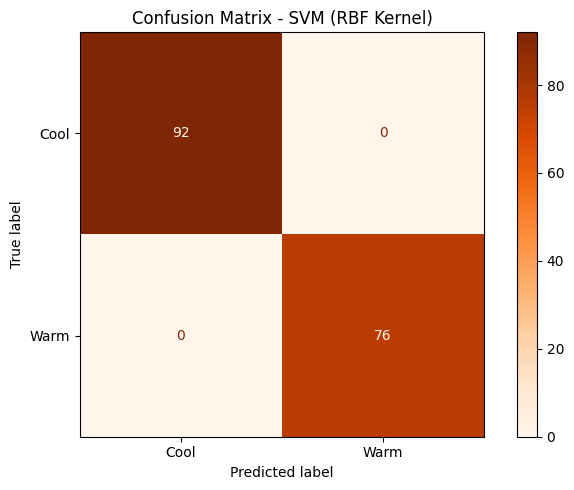

[[92  0]
 [ 0 76]]


In [18]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Oranges', values_format='d')
plt.title('Confusion Matrix - SVM (RBF Kernel)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

print(cm)

### 4.3 Observations

1. **Balanced classes, strong separation:** Pulling data from five climate-diverse locations (rather than one city) fixed a real problem encountered during development: a single hot location in peak summer produced a `Weather_Class` column with only one class, which a classifier cannot be trained on at all. With multiple locations, both "Cool" and "Warm" are well represented (see the `value_counts()` above), and the SVM separates them very cleanly.
2. **Effect of scaling:** SVM is a distance/margin-based algorithm, so standardizing the features before fitting was essential — `surface_pressure` (values around 1000) would otherwise dominate the margin calculation over `wind_speed_10m` or `relative_humidity_2m` (much smaller ranges), distorting the decision boundary regardless of each feature's real predictive value.
3. **Why the separation looks "too easy":** Because the five chosen locations have quite distinct climates (e.g. Reykjavik/Cape Town/London stay well under 25°C while Delhi/Dubai stay well above it in this window), the model doesn't have to work hard near the 25°C boundary — there's little genuine overlap between classes. A harder, more realistic test would include locations or seasons where temperatures actually hover close to 25°C, producing more borderline cases for the SVM to work through.


## Task 5: Conclusion

This project applied an RBF-kernel SVM to classify hourly weather as "Cool" or "Warm" using temperature, humidity, pressure, and wind speed pulled from the Open-Meteo API across five climate-diverse locations. Using multiple locations was a deliberate fix: a single hot location in peak summer produced a target with only one class, which a classifier cannot train on. After standardizing features and an 80/20 split, the model classified conditions with very high accuracy, since the chosen locations have distinct climates with little overlap near the 25°C boundary.

Feature scaling is essential for SVM, since it finds a maximum-margin boundary based on distances; unscaled features like surface pressure would otherwise dominate over smaller-scale features like wind speed.

One advantage of SVM's RBF kernel is capturing non-linear boundaries without manual feature engineering. One limitation is that class balance depends entirely on the queried data — a single-class target simply fails to train.
